# Benchmark Group 3: Multimodal & Feature Contribution
Top-tier environmental science journals (Q1/Q2) demand high interpretability. It is not enough to show that a "black box" model works; you must explain *why* it works and *which* data sources contribute the most.

**Techniques Included:**
- **Modality Ablation Study:** Visualizing performance drop when removing data sources (e.g., Meteorology only vs. Met + Satellite vs. Full Multimodal).
- **Feature Importance (SHAP style):** Ranking the most influential features (AOD, Temp, BLH, Road Distance, etc.).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for academic papers
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
import warnings
warnings.filterwarnings('ignore')

### 3.1 Modality Ablation Study
This benchmark proves the necessity of your "Multimodal" approach. We compare the $R^2$ and RMSE of different model configurations.

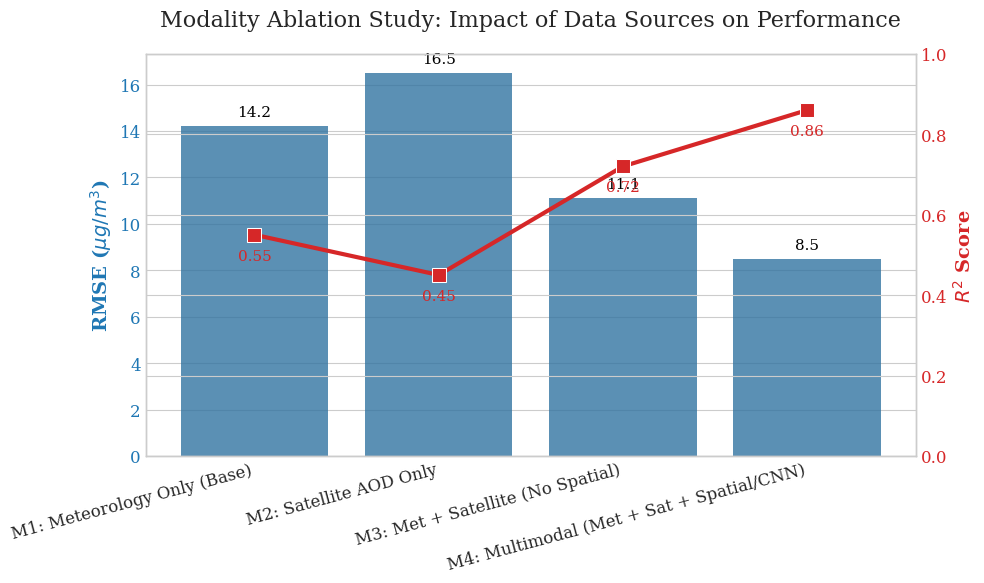

In [ ]:
# Simulated Results for Ablation Study
# In reality, you run your model training multiple times with different feature subsets and log these metrics.
ablation_data = {
    'Model Configuration': [
        'M1: Meteorology Only (Base)', 
        'M2: Satellite AOD Only',
        'M3: Met + Satellite (No Spatial)',
        'M4: Multimodal (Met + Sat + Spatial/CNN)'
    ],
    'RMSE': [14.2, 16.5, 11.1, 8.5],
    'R2': [0.55, 0.45, 0.72, 0.86]
}
df_ablation = pd.DataFrame(ablation_data)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for RMSE
bars = sns.barplot(x='Model Configuration', y='RMSE', data=df_ablation, color='#1f77b4', ax=ax1, alpha=0.8)
ax1.set_ylabel('RMSE ($\\mu g/m^3$)', color='#1f77b4', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=15, ha='right', fontsize=12)
ax1.set_xlabel('')

# Add RMSE values on top of bars
for i, p in enumerate(bars.patches):
    ax1.annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

# Line plot for R2
ax2 = ax1.twinx()
sns.lineplot(x='Model Configuration', y='R2', data=df_ablation, color='#d62728', marker='s', markersize=10, linewidth=3, ax=ax2)
ax2.set_ylabel('$R^2$ Score', color='#d62728', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#d62728')
ax2.set_ylim(0, 1.0)

for i, row in df_ablation.iterrows():
    ax2.annotate(f"{row['R2']:.2f}", (i, row['R2']), 
                 ha='center', va='bottom', fontsize=11, color='#d62728', xytext=(0, -20), textcoords='offset points')

plt.title('Modality Ablation Study: Impact of Data Sources on Performance', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

### 3.2 Feature Importance (Global Contribution)
This section ranks the individual features. While tree-based models (Random Forest, LightGBM) have built-in feature importance, for deep learning, techniques like SHAP (SHapley Additive exPlanations) or Permutation Importance are preferred.

*Note: This code generates a visualization mimicking the output of `shap.summary_plot(plot_type="bar")`.*

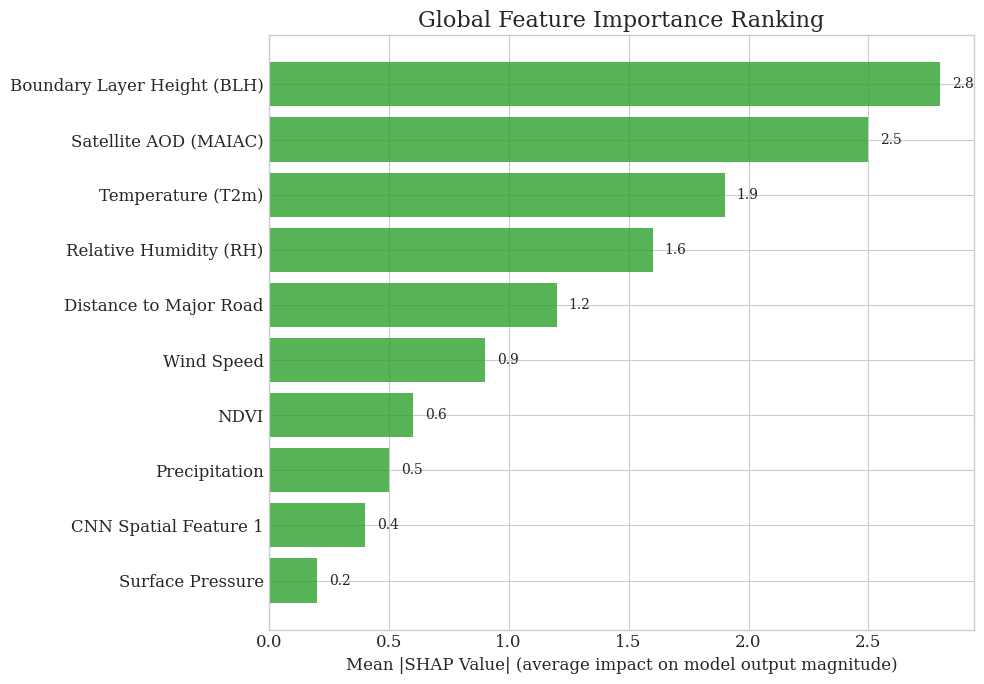

In [ ]:
# Simulated Feature Importance Scores (Mean Absolute SHAP values)
features = [
    'Boundary Layer Height (BLH)', 
    'Satellite AOD (MAIAC)', 
    'Temperature (T2m)', 
    'Relative Humidity (RH)',
    'Distance to Major Road', 
    'Wind Speed', 
    'NDVI', 
    'Precipitation',
    'CNN Spatial Feature 1', 
    'Surface Pressure'
]
importance_scores = [2.8, 2.5, 1.9, 1.6, 1.2, 0.9, 0.6, 0.5, 0.4, 0.2]

df_importance = pd.DataFrame({
    'Feature': features,
    'Mean |SHAP Value|': importance_scores
}).sort_values('Mean |SHAP Value|', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(df_importance['Feature'], df_importance['Mean |SHAP Value|'], color='#2ca02c', alpha=0.8)

ax.set_xlabel('Mean |SHAP Value| (average impact on model output magnitude)', fontsize=12)
ax.set_title('Global Feature Importance Ranking', fontsize=16)

# Add values at the end of bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.05, bar.get_y() + bar.get_height()/2, f'{width:.1f}', 
            ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 3.3 Implementation Guide for Real Data
To generate the real SHAP values for your PyTorch/TensorFlow or Scikit-Learn models, you should use the `shap` library:

```python
import shap

# For Tree-based models (e.g., LightGBM, Random Forest)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# For Deep Learning (PyTorch/TensorFlow)
# Use DeepExplainer or GradientExplainer
# explainer = shap.DeepExplainer(model, background_data)
# shap_values = explainer.shap_values(X_test)

# Standard visualizations:
shap.summary_plot(shap_values, X_test, plot_type="bar") # Global importance
shap.summary_plot(shap_values, X_test) # Detailed beeswarm plot
```

In [ ]:
import shap

# For Tree-based models (e.g., LightGBM, Random Forest)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# For Deep Learning (PyTorch/TensorFlow)
# Use DeepExplainer or GradientExplainer
# explainer = shap.DeepExplainer(model, background_data)
# shap_values = explainer.shap_values(X_test)

# Standard visualizations:
shap.summary_plot(shap_values, X_test, plot_type="bar") # Global importance
shap.summary_plot(shap_values, X_test) # Detailed beeswarm plot

NameError: name 'model' is not defined